# Mineração de Dados - FP-growth

A base de dados escolhida está disponível em : https://www.kaggle.com/datasets/blastchar/telco-customer-churn?resource=download

## EDA - Análise exploratória



### dicionario

**customerID**

Customer ID

ID do cliente


**gender**

Whether the customer is a male or a female

Sexo do cliente (Masculino ou Feminino)


**SeniorCitizen**

Whether the customer is a senior citizen or not (1, 0)

Se o cliente é idoso ou não (1, 0)


**Partner**

Whether the customer has a partner or not (Yes, No)

Se o cliente tem um parceiro ou não (Sim, Não)


**Dependents**

Whether the customer has dependents or not (Yes, No)

Se o cliente tem dependentes ou não (Sim, Não)


**tenure**

Number of months the customer has stayed with the company

Número de meses que o cliente permaneceu com a empresa


**PhoneService**

Whether the customer has a phone service or not (Yes, No)

Se o cliente tem serviço de telefone ou não (Sim, Não)


**MultipleLines**

Whether the customer has multiple lines or not (Yes, No, No phone service)

Se o cliente tem múltiplas linhas ou não (Sim, Não, Sem serviço de telefone)


**InternetService**

Customer’s internet service provider (DSL, Fiber optic, No)

Provedor de serviço de internet do cliente (DSL, Fibra óptica, Não)


**OnlineSecurity**

Whether the customer has online security or not (Yes, No, No internet service)

Se o cliente tem segurança online ou não (Sim, Não, Sem serviço de internet)


# O que é churn
Churn, ou rotatividade de clientes, é uma métrica que representa a perda de clientes de uma empresa em um determinado período, geralmente expressa como uma porcentagem. Ele ocorre quando clientes param de comprar um produto, cancelar assinaturas ou deixar de usar um serviço, impactando diretamente a receita. Calcular a taxa de churn (churn rate) é essencial para entender o desempenho de retenção de clientes, especialmente para empresas com modelos de negócio baseados em assinaturas.

## Análise

In [92]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [93]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'telco-customer-churn' dataset.
Path to dataset files: /kaggle/input/telco-customer-churn


In [94]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import fpgrowth, association_rules

dfchurn = pd.read_csv('/kaggle/input/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv', header=0)
dfchurn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [95]:
dfchurn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Realizando a contagem as categorias

In [96]:
# Equivalente a SELECT DISTINCT coluna1, coluna2 FROM tabela; mas ta tabela toda
print("Contagem de valores únicos por coluna no dfchurn:")
for col in dfchurn.columns:
    print(f"{col:<20}: {dfchurn[col].nunique()} valores únicos")

Contagem de valores únicos por coluna no dfchurn:
customerID          : 7043 valores únicos
gender              : 2 valores únicos
SeniorCitizen       : 2 valores únicos
Partner             : 2 valores únicos
Dependents          : 2 valores únicos
tenure              : 73 valores únicos
PhoneService        : 2 valores únicos
MultipleLines       : 3 valores únicos
InternetService     : 3 valores únicos
OnlineSecurity      : 3 valores únicos
OnlineBackup        : 3 valores únicos
DeviceProtection    : 3 valores únicos
TechSupport         : 3 valores únicos
StreamingTV         : 3 valores únicos
StreamingMovies     : 3 valores únicos
Contract            : 3 valores únicos
PaperlessBilling    : 2 valores únicos
PaymentMethod       : 4 valores únicos
MonthlyCharges      : 1585 valores únicos
TotalCharges        : 6531 valores únicos
Churn               : 2 valores únicos


#Fazendo o onehot encoding

In [97]:
# Converte 'TotalCharges' para númerico
dfchurn['TotalCharges'] = pd.to_numeric(dfchurn['TotalCharges'], errors='coerce')

# Tirando o NaN de totalcharges, já que pelo que me lembro NaN é como objeto
dfchurn.dropna(subset=['TotalCharges'], inplace=True)

# Tirando também as colunas SeniorCitizen, tenure, MonthlyCharges, TotalCharges
dfchurn.drop(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], axis=1, inplace=True)

# O One-Hot Encoding foi aplicado só as colunas "certas". O drop na coluna ID dos clientes foi feita porque se aplicasse nessa coluna só ia criar mais 7000 colunas
df_encoded = pd.get_dummies(dfchurn.drop('customerID', axis=1))

print("DataFrame após One-Hot Encoding:")
display(df_encoded.head())

DataFrame após One-Hot Encoding:


,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
0,True,False,False,True,True,False,True,False,False,True,...,False,False,False,True,False,False,True,False,True,False
1,False,True,True,False,True,False,False,True,True,False,...,True,False,True,False,False,False,False,True,True,False
2,False,True,True,False,True,False,False,True,True,False,...,False,False,False,True,False,False,False,True,False,True
3,False,True,True,False,True,False,True,False,False,True,...,True,False,True,False,True,False,False,False,True,False
4,True,False,True,False,True,False,False,True,True,False,...,False,False,False,True,False,False,True,False,False,True


In [98]:
df_matrix = df_encoded.drop('Churn_No', axis=1)
matrix_correlacao = df_matrix.corr(method='pearson')
print("Matriz de Correlação:")
display(matrix_correlacao)

Matriz de Correlação:


,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,MultipleLines_No phone service,...,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
gender_Female,1.000000,-1.000000,-0.001379,0.001379,0.010349,-0.010349,-0.007515,0.007515,-0.004335,-0.007515,...,0.003251,-0.007755,0.003603,-0.011902,0.011902,0.015973,-0.001632,-0.000844,-0.013199,0.008545
gender_Male,-1.000000,1.000000,0.001379,-0.001379,-0.010349,0.010349,0.007515,-0.007515,0.004335,0.007515,...,-0.003251,0.007755,-0.003603,0.011902,-0.011902,-0.015973,0.001632,0.000844,0.013199,-0.008545
Partner_No,-0.001379,0.001379,1.000000,-1.000000,0.452269,-0.452269,0.018397,-0.018397,0.130028,0.018397,...,0.280202,-0.083067,-0.247334,-0.013957,0.013957,-0.111406,-0.082327,0.083207,0.096948,0.149982
Partner_Yes,0.001379,-0.001379,-1.000000,1.000000,-0.452269,0.452269,-0.018397,0.018397,-0.130028,-0.018397,...,-0.280202,0.083067,0.247334,0.013957,-0.013957,0.111406,0.082327,-0.083207,-0.096948,-0.149982
Dependents_No,0.010349,-0.010349,0.452269,-0.452269,1.000000,-1.000000,-0.001078,0.001078,-0.023388,-0.001078,...,0.229715,-0.069222,-0.201699,-0.110131,0.110131,-0.052369,-0.061134,0.149274,-0.056448,0.163128
Dependents_Yes,-0.010349,0.010349,-0.452269,0.452269,-1.000000,1.000000,0.001078,-0.001078,0.023388,0.001078,...,-0.229715,0.069222,0.201699,0.110131,-0.110131,0.052369,0.061134,-0.149274,0.056448,-0.163128
PhoneService_No,-0.007515,0.007515,0.018397,-0.018397,-0.001078,0.001078,1.000000,-1.000000,-0.315218,1.000000,...,0.001243,0.003142,-0.004442,0.016696,-0.016696,-0.008271,0.006916,-0.002747,0.004463,-0.011691
PhoneService_Yes,0.007515,-0.007515,-0.018397,0.018397,0.001078,-0.001078,-1.000000,1.000000,0.315218,-1.000000,...,-0.001243,-0.003142,0.004442,-0.016696,0.016696,0.008271,-0.006916,0.002747,-0.004463,0.011691
MultipleLines_No,-0.004335,0.004335,0.130028,-0.130028,-0.023388,0.023388,-0.315218,0.315218,1.000000,-0.315218,...,0.086798,0.001694,-0.102756,0.151974,-0.151974,-0.069663,-0.063712,-0.080990,0.222395,-0.032654
MultipleLines_No phone service,-0.007515,0.007515,0.018397,-0.018397,-0.001078,0.001078,1.000000,-1.000000,-0.315218,1.000000,...,0.001243,0.003142,-0.004442,0.016696,-0.016696,-0.008271,0.006916,-0.002747,0.004463,-0.011691


# Matriz de correlação usando o coeficiênte de Pearson

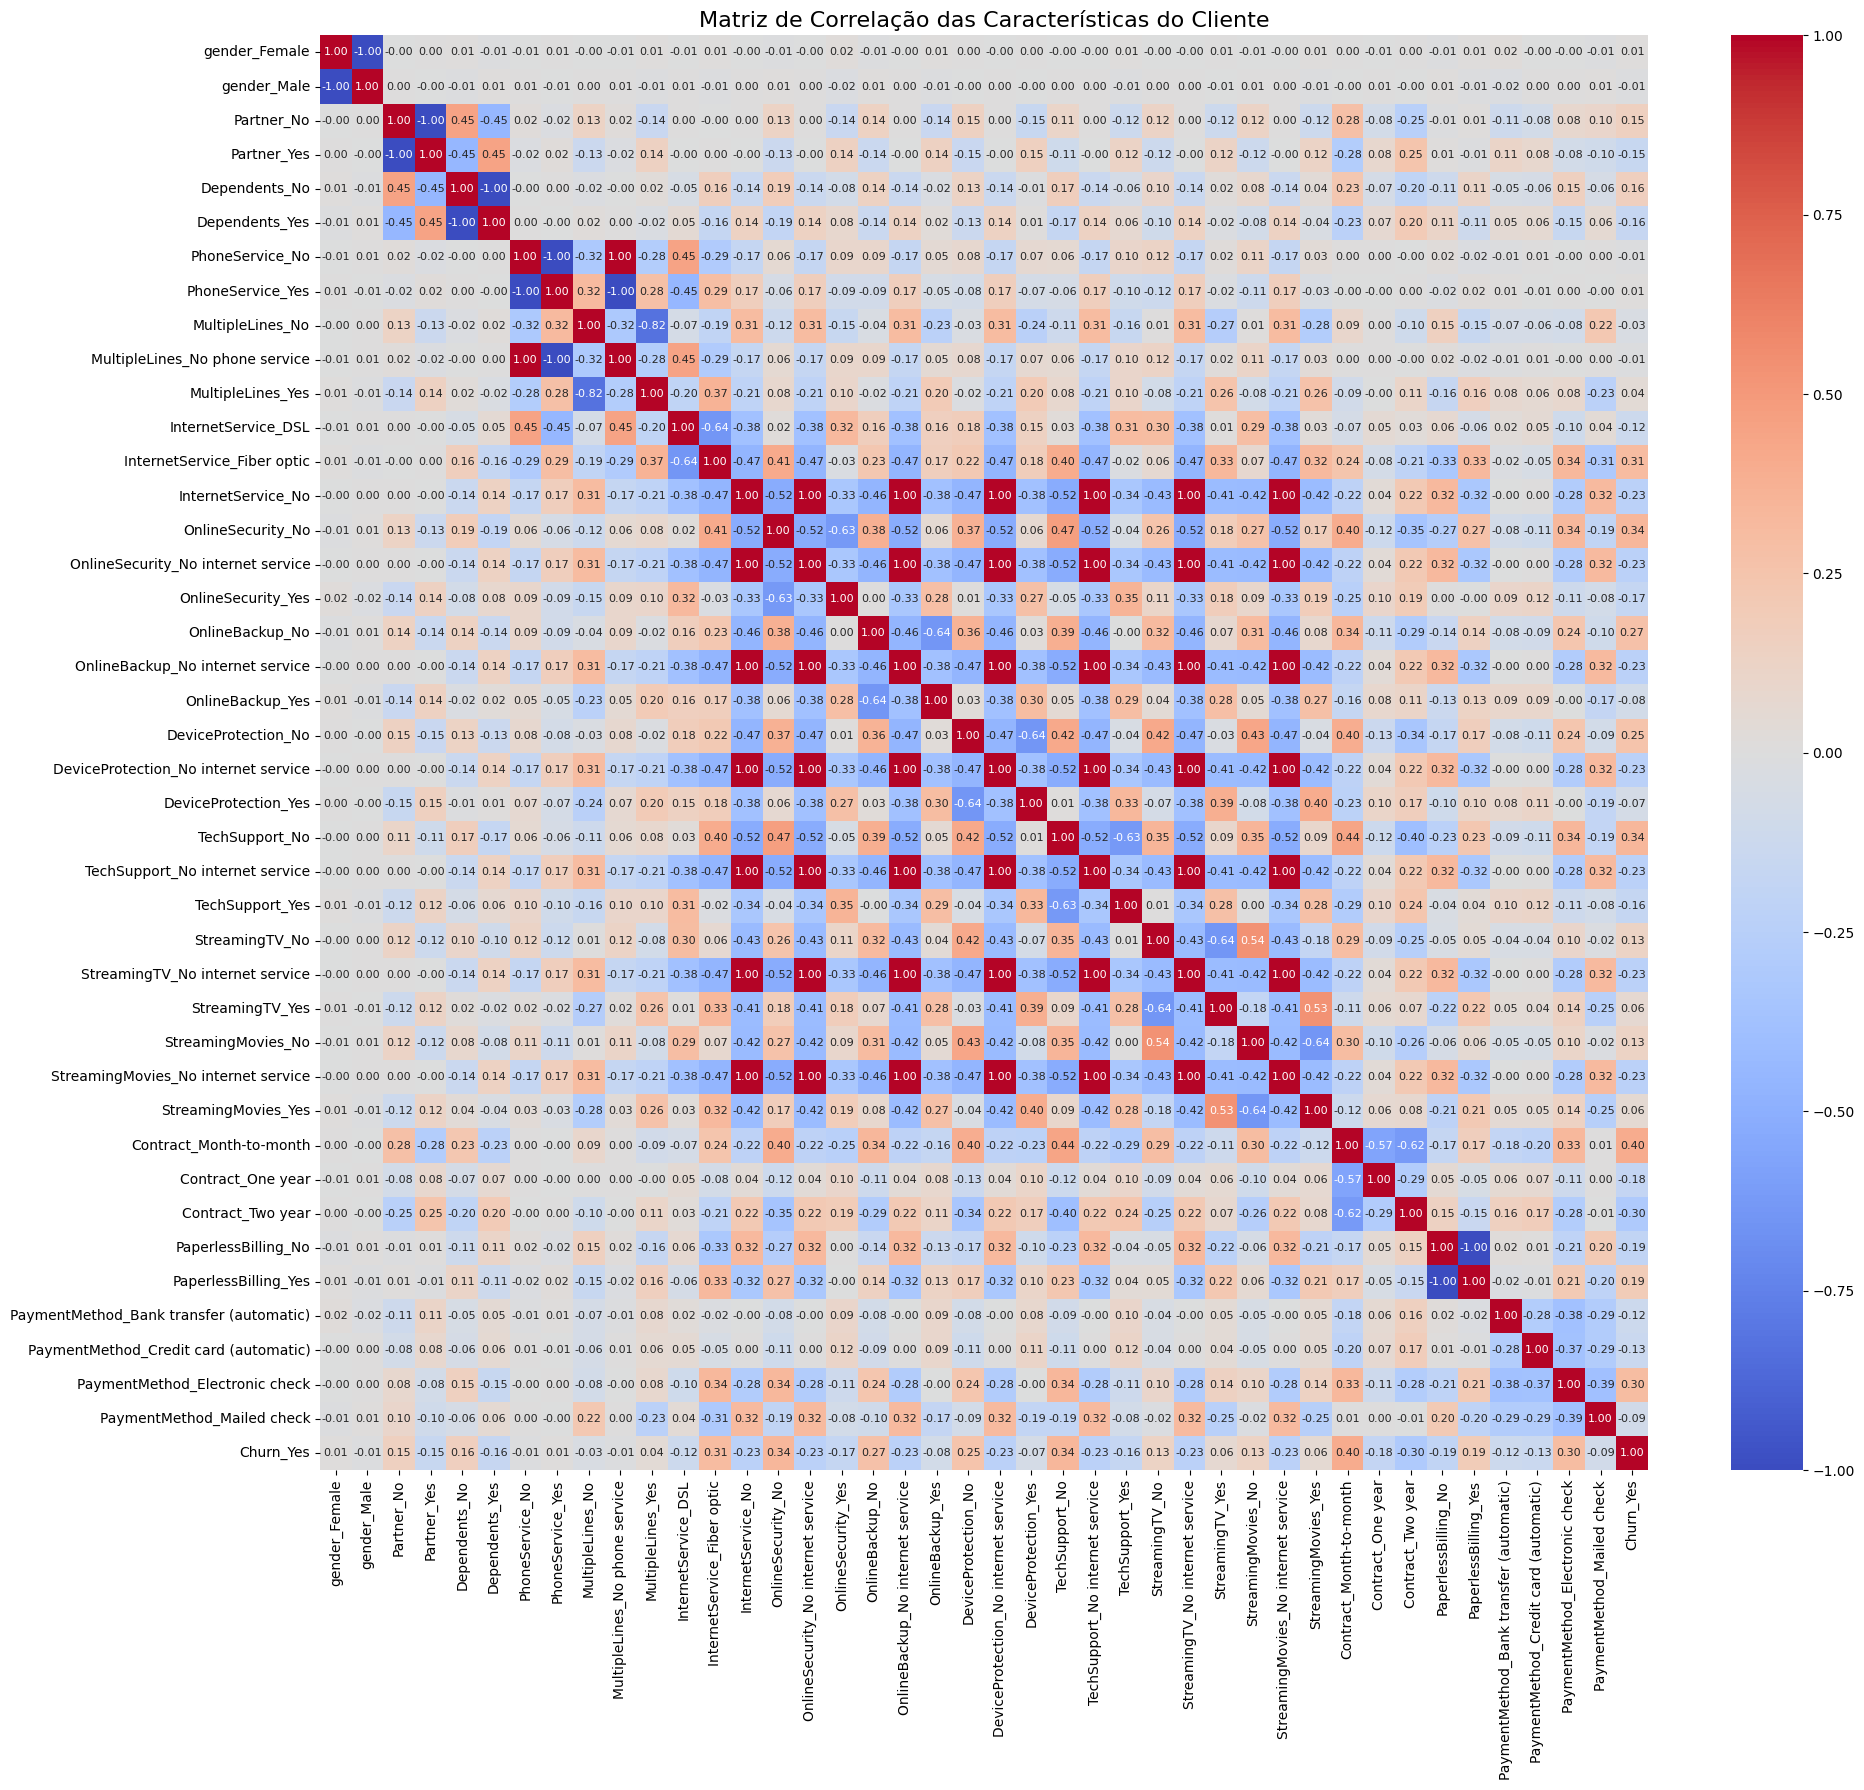

In [99]:
plt.figure(figsize=(20, 18)) # Aumenta o tamanho da figura
sns.heatmap(matrix_correlacao, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8}) # Reduz o tamanho da fonte da anotação e formata para 2 casas decimais
plt.xticks(rotation=90) # Rotaciona os rótulos do eixo X para melhor legibilidade
plt.yticks(rotation=0)  # Mantém os rótulos do eixo Y na horizontal
plt.title('Matriz de Correlação das Características do Cliente', fontsize=16) # Adiciona um título
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

# Mesma matriz mas triângular inferior

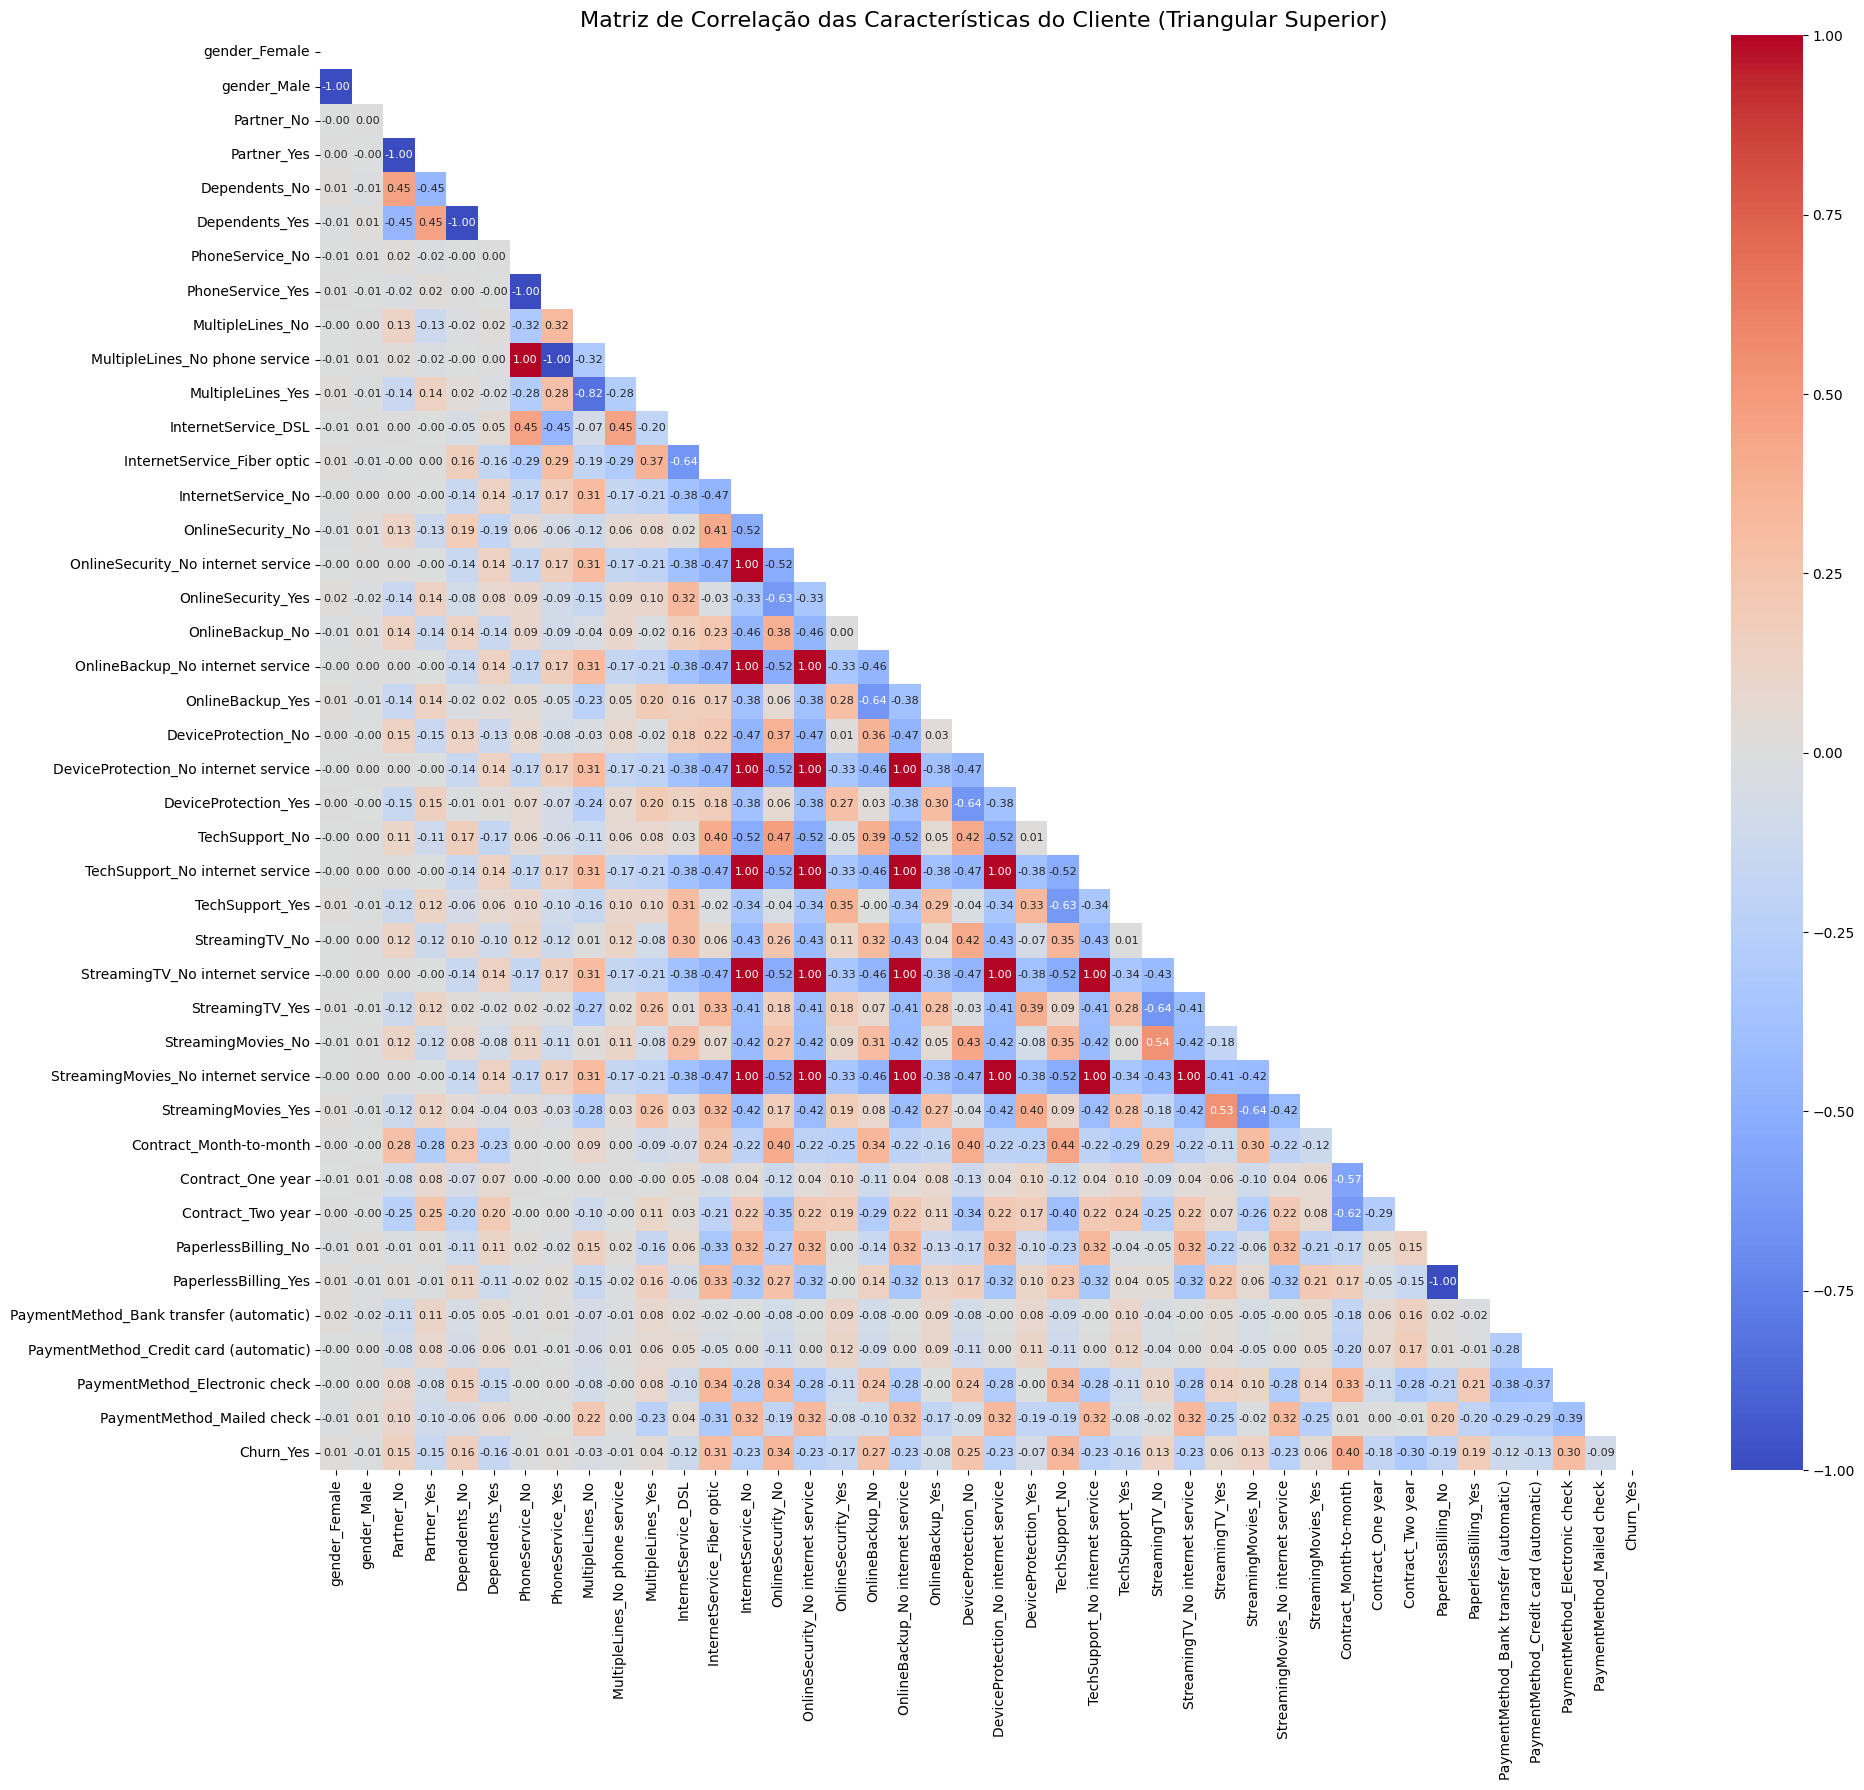

In [100]:
#Criando uma máscra, coisa nova qui aprendi
mask = np.triu(matrix_correlacao) # np.triu cria uma matriz com zeros abaixo da diagonal principal

plt.figure(figsize=(20, 18)) # Aumenta o tamanho da figura
sns.heatmap(matrix_correlacao, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 8}, mask=mask) # Adiciona a máscara
plt.xticks(rotation=90) # Rotaciona os rótulos do eixo X para melhor legibilidade
plt.yticks(rotation=0)  # Mantém os rótulos do eixo Y na horizontal
plt.title('Matriz de Correlação das Características do Cliente (Triangular Superior)', fontsize=16) # Adiciona um título
plt.tight_layout() # Ajusta o layout para evitar sobreposição
plt.show()

Algo importante aqui.
+1 -> Correlação positiva
-1 -> Correlação negativa
0 -> Não há correlação

Por ter aplicado o onehot encoding, as correlações fortes são estruturais e não comportamentais.

O que isso quer dizer?

Por exemplo, se a pessoa não tem InternetService_No consequentemente ela não vai ter InternetService_Fiber optic. Ou seja, se um é verdadeiro o outro é falso.
**Essas correlações não indicam relação causal ou preditiva, apenas dependência lógica.**

IPC: correlação ≠ causalidade

#Aplicação do algoritmo pfgrowth

In [101]:
partes_frequentes = fpgrowth(df_encoded, min_support=0.20, use_colnames=True)
print("Partes frequentes encontradas:")
display(partes_frequentes)

# Filtrando 'Churn_Yes'
algortimo_churn_yes = partes_frequentes[partes_frequentes['itemsets'].apply(lambda x: 'Churn_Yes' in x)]

print("\nPartes frequentes que incluem 'Churn_Yes':")
display(algortimo_churn_yes)

Partes frequentes encontradas:


,support,itemsets
0,0.734215,(Churn_No)
1,0.701507,(Dependents_No)
2,0.592719,(PaperlessBilling_Yes)
3,0.551052,(Contract_Month-to-month)
4,0.497298,(OnlineSecurity_No)
...,...,...
1131,0.200085,"(StreamingTV_No internet service, StreamingMov..."
1132,0.200085,"(StreamingTV_No internet service, TechSupport_..."
1133,0.200085,"(StreamingTV_No internet service, TechSupport_..."
1134,0.200085,"(StreamingTV_No internet service, TechSupport_..."



Partes frequentes que incluem 'Churn_Yes':


,support,itemsets
24,0.265785,(Churn_Yes)
494,0.241610,"(PhoneService_Yes, Churn_Yes)"
495,0.235353,"(Contract_Month-to-month, Churn_Yes)"
496,0.219425,"(Dependents_No, Churn_Yes)"
497,0.205631,"(TechSupport_No, Churn_Yes)"
498,0.207765,"(OnlineSecurity_No, Churn_Yes)"
499,0.213595,"(Contract_Month-to-month, PhoneService_Yes, Ch..."


# **Métricas**

* Support
* Cofidence
* Lift
* Conviction

# **Support**

$$support(A→B)=P(A∩B)$$
<br>
* É a frequência com que um item (ou conjunto de itens) aparece no dataset.
* Mede quão comum é a combinação A e B.
* Mede relevância estatística
* Evita regras raras e enganosas

# Executando o suporte

In [102]:
regras_support = association_rules(
    partes_frequentes,
    metric="support",
    min_threshold=0.5
    )

# Ordenando o suporte

In [103]:
support_sort = regras_support.sort_values(by='support', ascending=False)
display(support_sort[['antecedents','consequents','support','confidence','lift','support']])

,antecedents,consequents,support,confidence,lift,support
0,(Churn_No),(PhoneService_Yes),0.661689,0.901220,0.997698,0.661689
1,(PhoneService_Yes),(Churn_No),0.661689,0.732525,0.997698,0.661689
2,(Dependents_No),(PhoneService_Yes),0.633817,0.903507,1.000230,0.633817
3,(PhoneService_Yes),(Dependents_No),0.633817,0.701669,1.000230,0.633817
4,(PaperlessBilling_Yes),(PhoneService_Yes),0.537827,0.907390,1.004528,0.537827
5,(PhoneService_Yes),(PaperlessBilling_Yes),0.537827,0.595403,1.004528,0.537827


# **Confidence**
$$confidence(A\rightarrow B) = P(B|A) = \frac{support(A \cap B)}{support(A)}$$
<br>
* Valores maiores implica em maior força entre as regras e vice versa.
* É a probabilidade de o consequente ocorrer, dado que o antecedente ocorreu.
* Se X ocorreu, o quanto isso interfere para Y acontecer
* Mede a força da regra, o quanto o antecedente realmente “implica” o consequente.

#Executando a confidence

In [104]:
regras_confidence = association_rules(
    partes_frequentes,
    metric="confidence",
    min_threshold=0.7
    )

# Ordenando à Confiança (Confidence)

In [105]:
confidence_sort = regras_confidence.sort_values(by='confidence', ascending=False)
display(confidence_sort[['antecedents','consequents','support','confidence','lift','conviction']])

,antecedents,consequents,support,confidence,lift,conviction
19164,"(Churn_No, StreamingMovies_No internet service)","(StreamingTV_No internet service, TechSupport_...",0.200085,1.000000,4.626316,inf
19158,"(Churn_No, TechSupport_No internet service)","(StreamingTV_No internet service, OnlineSecuri...",0.200085,1.000000,4.626316,inf
19151,"(Churn_No, StreamingTV_No internet service)","(TechSupport_No internet service, OnlineSecuri...",0.200085,1.000000,4.626316,inf
19145,"(Churn_No, InternetService_No, PhoneService_Yes)","(StreamingTV_No internet service, TechSupport_...",0.200085,1.000000,4.626316,inf
19143,"(Churn_No, PhoneService_Yes, DeviceProtection_...","(StreamingTV_No internet service, TechSupport_...",0.200085,1.000000,4.626316,inf
...,...,...,...,...,...,...
771,"(PaperlessBilling_Yes, OnlineBackup_No)","(Contract_Month-to-month, PhoneService_Yes)",0.206911,0.700530,1.407866,1.677687
1114,(StreamingMovies_Yes),(Churn_No),0.272042,0.700476,0.954048,0.887358
366,"(DeviceProtection_No, PhoneService_Yes)",(PaperlessBilling_Yes),0.270620,0.700405,1.181681,1.359438
679,"(TechSupport_No, Contract_Month-to-month)",(OnlineBackup_No),0.266923,0.700373,1.595408,1.872352


# **Lift**
$$lift(A\rightarrow B) = \frac{confidence(A\rightarrow B)}{support(B)}$$
<br>
* É a razão entre a confiança da regra e o suporte do consequente.
* O lift mede a força da correlação entre os itens
* Mede o quanto A aumenta (ou diminui) a probabilidade de ocorrer B, comparado ao acaso.
* Lift = 1 → A não influencia B
* Lift > 1 → A aumenta a chance de B
* Lift < 1 → A reduz a chance de B

# Executando o lift

In [106]:
regras_lift = association_rules(
    partes_frequentes,
    metric="lift",
    min_threshold=1.2
    )

# Ordenando o lift

In [107]:
confidence_lift = regras_lift.sort_values(by='lift', ascending=True)
display(confidence_lift[['antecedents','consequents','support','confidence','lift','conviction']])

,antecedents,consequents,support,confidence,lift,conviction
424,"(TechSupport_No, Partner_No)",(PaperlessBilling_Yes),0.201081,0.711268,1.200008,1.410583
427,(PaperlessBilling_Yes),"(TechSupport_No, Partner_No)",0.201081,0.339251,1.200008,1.085575
737,(PaperlessBilling_Yes),"(DeviceProtection_No, Contract_Month-to-month)",0.242179,0.408589,1.200167,1.115225
736,"(DeviceProtection_No, Contract_Month-to-month)",(PaperlessBilling_Yes),0.242179,0.711362,1.200167,1.411043
743,(PaperlessBilling_Yes),"(Dependents_No, DeviceProtection_No)",0.240330,0.405470,1.200533,1.113919
...,...,...,...,...,...,...
2458,(StreamingTV_No internet service),"(OnlineBackup_No internet service, PhoneServic...",0.216155,1.000000,4.626316,inf
2457,"(OnlineBackup_No internet service, PhoneServic...",(StreamingTV_No internet service),0.216155,1.000000,4.626316,inf
2456,"(StreamingTV_No internet service, PhoneService...",(OnlineBackup_No internet service),0.216155,1.000000,4.626316,inf
2453,(OnlineBackup_No internet service),(StreamingTV_No internet service),0.216155,1.000000,4.626316,inf


# **Conviction**
$$conviction(A\rightarrow B) = \frac{1 - support(B)}{1 - confidence(A\rightarrow B)}$$
<br>
* É uma métrica alternativa ao lift que mede a confiança de que A ocorre sem B em comparação com os casos onde a regra é violada.
* Mede o grau de certeza de que, quando A ocorre, B também ocorrerá (quanto maior, mais forte a regra).
* '>= 1', quanto maior, mais forte a implicação
* Conviction ≈ 1 → regra fraca
* Sensível a erros da regra
* ∞	A implica B com confiança 100%
* “Quando A acontece, quão raro é B não acontecer?”

# Executando a conviction

In [108]:
regras_conviction = association_rules(
    partes_frequentes,
    metric="conviction",
    min_threshold=2.0
    )

# Ordenando a conviction

In [109]:
conviction_sort = regras_conviction.sort_values(by='conviction', ascending=False)
display(conviction_sort[['antecedents','consequents','support','confidence','lift','conviction']])

,antecedents,consequents,support,confidence,lift,conviction
18561,"(Churn_No, InternetService_No)","(StreamingTV_No internet service, TechSupport_...",0.200085,1.000000,4.626316,inf
18540,"(Churn_No, TechSupport_No internet service)","(StreamingTV_No internet service, OnlineSecuri...",0.200085,1.000000,4.626316,inf
18533,"(Churn_No, StreamingTV_No internet service)","(TechSupport_No internet service, OnlineSecuri...",0.200085,1.000000,4.626316,inf
18527,"(Churn_No, InternetService_No, PhoneService_Yes)","(StreamingTV_No internet service, TechSupport_...",0.200085,1.000000,4.626316,inf
18525,"(Churn_No, PhoneService_Yes, DeviceProtection_...","(StreamingTV_No internet service, TechSupport_...",0.200085,1.000000,4.626316,inf
...,...,...,...,...,...,...
274,"(Dependents_No, OnlineBackup_No, PhoneService_...",(TechSupport_No),0.222696,0.747494,1.513934,2.004931
293,"(Dependents_No, OnlineBackup_No)",(OnlineSecurity_No),0.254124,0.749266,1.506674,2.004923
128,"(Dependents_No, DeviceProtection_No, PhoneServ...",(OnlineSecurity_No),0.223976,0.748930,1.505998,2.002239
143,"(TechSupport_No, DeviceProtection_No, Contract...","(OnlineSecurity_No, PhoneService_Yes)",0.202361,0.720506,1.635442,2.001629


# Analisando os dados referente a churn_yes
Ver as regras que mais levam ao churn

# Lift do Churn_Yes

In [110]:
# Filtrando as regras que possuem lift maior que 1. Pode parecer estranho, mas o comando abaixo calcula todas as regras, e retorna aquelas que são maiores que 1.
rules = association_rules(
    partes_frequentes,
    metric="lift",
    min_threshold=1.0
    )

churn_rules = regras_lift[regras_lift['consequents'].apply(lambda x: 'Churn_Yes' in x)]
display(regras_lift)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,"(Dependents_No, PaperlessBilling_Yes)",(Contract_Month-to-month),0.440557,0.551052,0.300910,0.683021,1.239485,1.0,0.058140,1.416334,0.345368,0.435660,0.293952,0.614543
1,(Contract_Month-to-month),"(Dependents_No, PaperlessBilling_Yes)",0.551052,0.440557,0.300910,0.546065,1.239485,1.0,0.058140,1.232427,0.430370,0.435660,0.188593,0.614543
2,"(Dependents_No, PaperlessBilling_Yes, PhoneSer...",(Contract_Month-to-month),0.398606,0.551052,0.272184,0.682840,1.239156,1.0,0.052531,1.415523,0.320920,0.401763,0.293548,0.588388
3,"(Dependents_No, PaperlessBilling_Yes)","(Contract_Month-to-month, PhoneService_Yes)",0.440557,0.497582,0.272184,0.617818,1.241639,1.0,0.052971,1.314603,0.347870,0.408712,0.239314,0.582416
4,"(Contract_Month-to-month, PhoneService_Yes)","(Dependents_No, PaperlessBilling_Yes)",0.497582,0.440557,0.272184,0.547013,1.241639,1.0,0.052971,1.235009,0.387353,0.408712,0.190289,0.582416
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20591,(OnlineSecurity_No internet service),"(StreamingTV_No internet service, TechSupport_...",0.216155,0.200085,0.200085,0.925658,4.626316,1.0,0.156836,10.759914,1.000000,0.925658,0.907062,0.962829
20592,(OnlineBackup_No internet service),"(StreamingTV_No internet service, TechSupport_...",0.216155,0.200085,0.200085,0.925658,4.626316,1.0,0.156836,10.759914,1.000000,0.925658,0.907062,0.962829
20593,(DeviceProtection_No internet service),"(StreamingTV_No internet service, TechSupport_...",0.216155,0.200085,0.200085,0.925658,4.626316,1.0,0.156836,10.759914,1.000000,0.925658,0.907062,0.962829
20594,(Churn_No),"(StreamingTV_No internet service, TechSupport_...",0.734215,0.216155,0.200085,0.272516,1.260745,1.0,0.041381,1.077474,0.778141,0.266679,0.071904,0.599087


In [111]:
regras_metricas = rules.drop(['antecedent support', 'consequent support', 'representativity', 'leverage', 'zhangs_metric', 'jaccard', 'certainty', 'kulczynski'], axis=1, inplace=False)
display(regras_metricas)

,antecedents,consequents,support,confidence,lift,conviction
0,(Dependents_No),(PhoneService_Yes),0.633817,0.903507,1.000230,1.002153
1,(PhoneService_Yes),(Dependents_No),0.633817,0.701669,1.000230,1.000541
2,(Dependents_No),(PaperlessBilling_Yes),0.440557,0.628015,1.059550,1.094887
3,(PaperlessBilling_Yes),(Dependents_No),0.440557,0.743282,1.059550,1.162726
4,(PaperlessBilling_Yes),(PhoneService_Yes),0.537827,0.907390,1.004528,1.044168
...,...,...,...,...,...,...
22063,(OnlineBackup_No internet service),"(StreamingTV_No internet service, TechSupport_...",0.200085,0.925658,4.626316,10.759914
22064,(DeviceProtection_No internet service),"(StreamingTV_No internet service, TechSupport_...",0.200085,0.925658,4.626316,10.759914
22065,(Churn_No),"(StreamingTV_No internet service, TechSupport_...",0.200085,0.272516,1.260745,1.077474
22066,(InternetService_No),"(StreamingTV_No internet service, TechSupport_...",0.200085,0.925658,4.626316,10.759914


# Gráfico que mostra as regras que mais possuem churn_yes de acordo com o LIFT

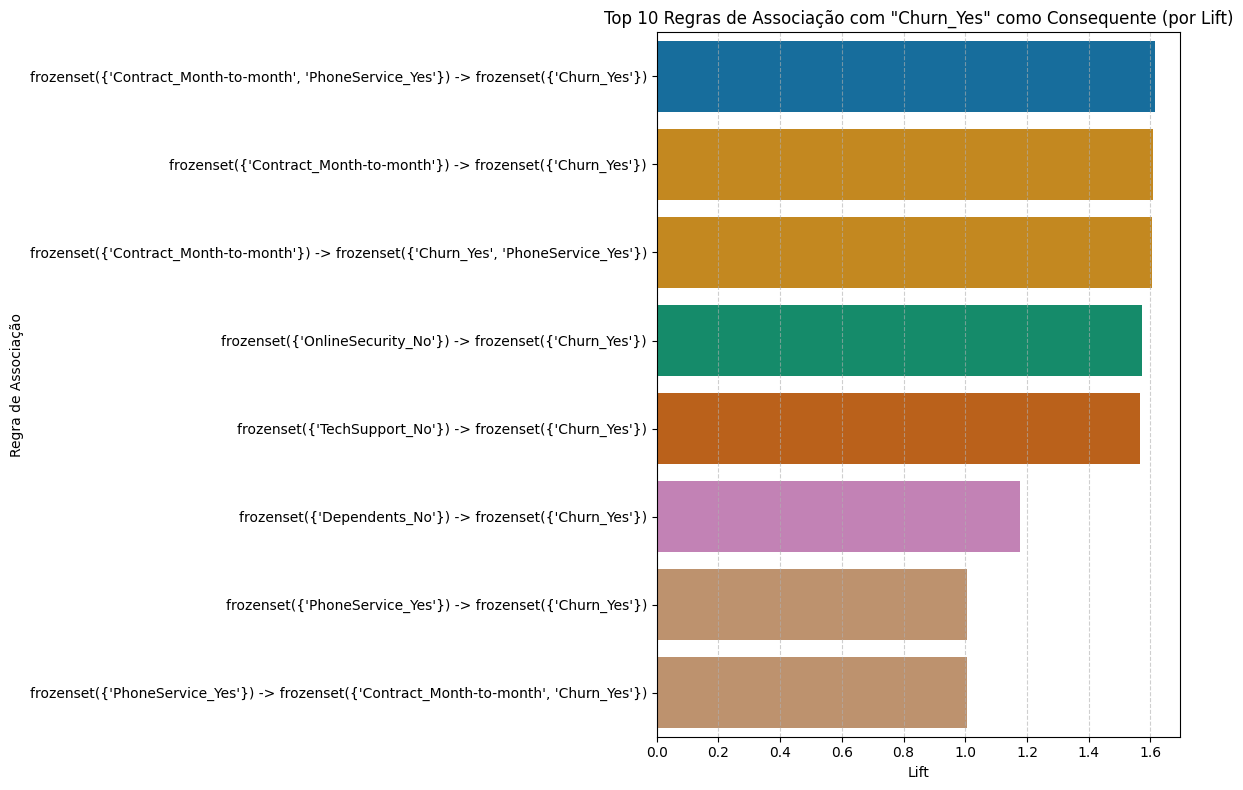

In [112]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrando as regras que o churn_yes é consequente. Ou sejao que lea ao churn
churn_rules = rules[rules['consequents'].apply(lambda x: 'Churn_Yes' in x)]

# Ordenando pelo lift
churn_rules_sorted_lift = churn_rules.sort_values(by='lift', ascending=False)

top_n = 10
top_churn_rules = churn_rules_sorted_lift.head(top_n)


plt.figure(figsize=(12, 8))
sns.barplot(
    x='lift',
    y=top_churn_rules['antecedents'].astype(str) + ' -> ' + top_churn_rules['consequents'].astype(str),
    hue='antecedents',
    data=top_churn_rules,
    palette='colorblind',
    legend= False)

plt.title(f'Top {top_n} Regras de Associação com "Churn_Yes" como Consequente (por Lift)')
plt.xlabel('Lift')
plt.ylabel('Regra de Associação')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [113]:
print(f"\nTop {top_n} Regras de Associação com 'Churn_Yes':")
display(top_churn_rules)


Top 10 Regras de Associação com 'Churn_Yes':


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
2452,"(Contract_Month-to-month, PhoneService_Yes)",(Churn_Yes),0.497582,0.265785,0.213595,0.429266,1.615086,1.0,0.081345,1.286439,0.758011,0.388515,0.222660,0.616452
2444,(Contract_Month-to-month),(Churn_Yes),0.551052,0.265785,0.235353,0.427097,1.606926,1.0,0.088891,1.281569,0.841287,0.404744,0.219706,0.656299
2455,(Contract_Month-to-month),"(Churn_Yes, PhoneService_Yes)",0.551052,0.241610,0.213595,0.387613,1.604293,1.0,0.080455,1.238416,0.839012,0.368861,0.192517,0.635831
2450,(OnlineSecurity_No),(Churn_Yes),0.497298,0.265785,0.207765,0.417787,1.571897,1.0,0.075590,1.261076,0.723741,0.374136,0.207026,0.599744
2448,(TechSupport_No),(Churn_Yes),0.493743,0.265785,0.205631,0.416475,1.566961,1.0,0.074402,1.258240,0.714700,0.371245,0.205239,0.595075
2446,(Dependents_No),(Churn_Yes),0.701507,0.265785,0.219425,0.312791,1.176859,1.0,0.032975,1.068402,0.503464,0.293402,0.064023,0.569183
2442,(PhoneService_Yes),(Churn_Yes),0.903299,0.265785,0.241610,0.267475,1.006358,1.0,0.001526,1.002307,0.065333,0.260503,0.002302,0.588259
2456,(PhoneService_Yes),"(Contract_Month-to-month, Churn_Yes)",0.903299,0.235353,0.213595,0.236461,1.004709,1.0,0.001001,1.001452,0.048469,0.230899,0.001449,0.572007


* 21% dos clientes têm contrato mensal e não têm segurança online.
* Entre eles, 42% tiveram o caso do churn.
* Isso é 60% mais churn do que o normal da base.

#Regras mais fortes, por confidence, lift e convi
Aquelas que mais levam a outras, antecedente leva consequente

In [114]:
regras_fortes = regras_lift[
    (regras_lift['lift'] > 1.0) &
    (regras_confidence['confidence'] > 0.6) &
    (regras_conviction['conviction'] > 1.5)
]
regras_fortes.sort_values(by='lift', ascending=False).head(10)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
18569,(TechSupport_No internet service),"(StreamingTV_No internet service, StreamingMov...",0.216155,0.200085,0.200085,0.925658,4.626316,1.0,0.156836,10.759914,1.000000,0.925658,0.907062,0.962829
18568,(StreamingTV_No internet service),"(TechSupport_No internet service, StreamingMov...",0.216155,0.200085,0.200085,0.925658,4.626316,1.0,0.156836,10.759914,1.000000,0.925658,0.907062,0.962829
18567,"(Churn_No, InternetService_No)","(StreamingTV_No internet service, TechSupport_...",0.200085,0.216155,0.200085,1.000000,4.626316,1.0,0.156836,inf,0.979911,0.925658,1.000000,0.962829
18566,"(InternetService_No, DeviceProtection_No inter...","(StreamingTV_No internet service, TechSupport_...",0.216155,0.200085,0.200085,0.925658,4.626316,1.0,0.156836,10.759914,1.000000,0.925658,0.907062,0.962829
18565,"(Churn_No, DeviceProtection_No internet service)","(StreamingTV_No internet service, TechSupport_...",0.200085,0.216155,0.200085,1.000000,4.626316,1.0,0.156836,inf,0.979911,0.925658,1.000000,0.962829
18548,"(OnlineSecurity_No internet service, TechSuppo...","(StreamingTV_No internet service, StreamingMov...",0.216155,0.200085,0.200085,0.925658,4.626316,1.0,0.156836,10.759914,1.000000,0.925658,0.907062,0.962829
18547,"(StreamingMovies_No internet service, TechSupp...","(StreamingTV_No internet service, OnlineSecuri...",0.216155,0.200085,0.200085,0.925658,4.626316,1.0,0.156836,10.759914,1.000000,0.925658,0.907062,0.962829
18546,"(InternetService_No, StreamingTV_No internet s...","(TechSupport_No internet service, Churn_No, On...",0.216155,0.200085,0.200085,0.925658,4.626316,1.0,0.156836,10.759914,1.000000,0.925658,0.907062,0.962829
18545,"(Churn_No, StreamingTV_No internet service)","(TechSupport_No internet service, OnlineSecuri...",0.200085,0.216155,0.200085,1.000000,4.626316,1.0,0.156836,inf,0.979911,0.925658,1.000000,0.962829
18544,"(StreamingTV_No internet service, DeviceProtec...","(TechSupport_No internet service, StreamingMov...",0.216155,0.200085,0.200085,0.925658,4.626316,1.0,0.156836,10.759914,1.000000,0.925658,0.907062,0.962829
